Q1] Fragment length frequency

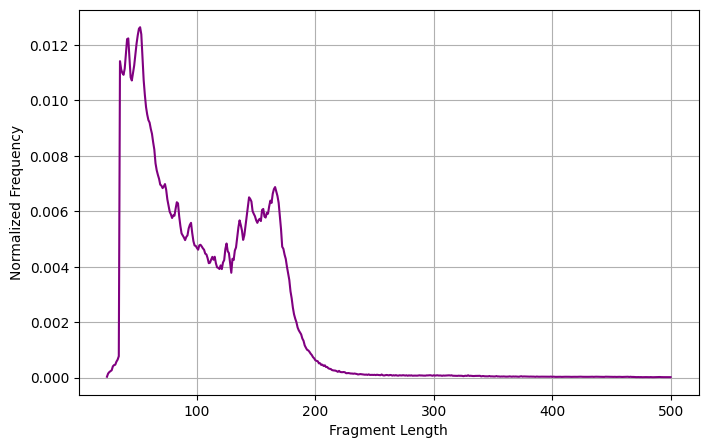

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from collections import Counter

query = pd.read_csv('query.bed', sep='\t', header=None)
lengths = Counter(query.iloc[:, 2]-query.iloc[:,1])

total = sum(lengths.values())
normalized_freq = {k: v / total for k, v in lengths.items()}
x, y = zip(*sorted(normalized_freq.items()))
q_df = pd.DataFrame({'Fragment Length': x, 'Normalized Frequency': y})
# Now plot
plt.figure(figsize=(8, 5))
plt.plot(q_df.iloc[:,0], q_df.iloc[:,1], color='purple')
plt.xlabel('Fragment Length')
plt.ylabel('Normalized Frequency')
plt.grid(True)
plt.show()


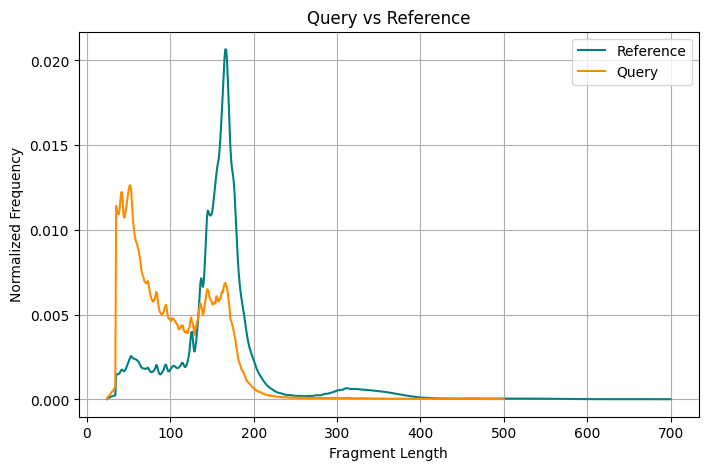

In [7]:
ref = pd.read_csv('reference.hist', sep='\t', header=None)

# Plot both
plt.figure(figsize=(8, 5))
plt.plot(ref.iloc[:,0], ref.iloc[:,1], color='teal',label='Reference')
plt.plot(x, y, color='darkorange',label='Query')
plt.legend()
plt.xlabel('Fragment Length')
plt.ylabel('Normalized Frequency')
plt.grid(True)
plt.title('Query vs Reference')
plt.show()

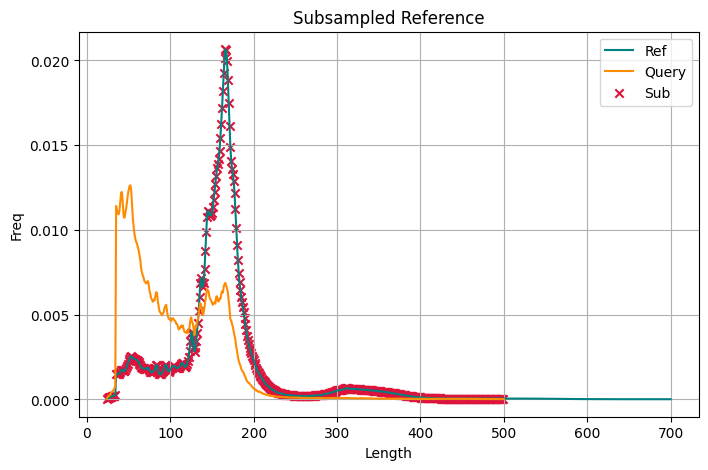

In [8]:
# Bin settings
edges = list(range(0, 510, 10))
labels = [f"{i}-{i+10}" for i in range(0, 500, 10)]

# Bin values
q_df['bin'] = pd.cut(q_df.iloc[:,0], bins=edges, labels=labels, right=False)
ref['bin'] = pd.cut(ref.iloc[:, 0], bins=edges, labels=labels, right=False)

# Count bins
q_bin = q_df['bin'].value_counts().sort_index()
ref_bin = ref['bin'].value_counts().sort_index()

# Sampling
samples = []

for b in labels:
    count_q_df = q_bin.get(b, 0)
    count_ref = ref_bin.get(b, 0)

    sample_size = min(count_q_df, count_ref)
    n = min(count_q_df, count_ref)

    if n > 0:
        r_rows = ref[ref['bin'] == b]
        picked = r_rows.sample(n=n, random_state=42)
        samples.append(picked)

# Combine samples
sub_df = pd.concat(samples, ignore_index=True)

plt.figure(figsize=(8, 5))
plt.plot(ref.iloc[:, 0], ref.iloc[:, 1], color='teal', label='Ref')
plt.plot(x, y, color='darkorange', label='Query')
plt.scatter(sub_df.iloc[:, 0], sub_df.iloc[:, 1], color='crimson', label='Sub', marker='x')
plt.legend()
plt.xlabel('Length')
plt.ylabel('Freq')
plt.grid(True)
plt.title('Subsampled Reference')
plt.show()